
# CBottle การสร้างและการเติมข้อมูล

สภาพภูมิอากาศในขวด (cBottle) inference workflows สำหรับการสังเคราะห์ข้อมูลสภาพอากาศทั่วโลก

ตัวอย่างนี้จะสาธิตแหล่งข้อมูลโมเดลการแพร่กระจาย cBottle และการเติม
Diagnostic Model สำหรับสร้างข้อมูลสภาพอากาศและสภาพอากาศทั่วโลก ทั้งข้อมูล cBottle
การวินิจฉัยแหล่งที่มาและการเติมจะใช้โมเดลการแพร่กระจายเดียวกัน แต่ขั้นตอนการสุ่มตัวอย่าง
จะแตกต่างกันทำให้สามารถโต้ตอบได้สองโหมดที่เป็นเอกลักษณ์

ดูข้อมูลเพิ่มเติมเกี่ยวกับ cBottle ได้ที่:

- https://arxiv.org/abs/2505.06474v1

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- การสร้างข้อมูลสภาพภูมิอากาศสังเคราะห์ด้วยแหล่งข้อมูล cBottle
- การสร้างอินสแตนซ์ cBottle เติม Diagnostic Model
- การสร้าง inference workflow แบบเติมข้อมูลอย่างง่าย


In [1]:
# /// script
# dependencies = [
#   "earth2studio[cbottle] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
สำหรับตัวอย่างนี้ เราจะใช้แหล่งข้อมูล cBottle และการวินิจฉัยการเติมข้อมูล ไม่เหมือน
แหล่งข้อมูลอื่นๆ ที่ต้องโหลดแหล่งข้อมูล cBottle3D คล้ายกับ
การพยากรณ์หรือ Diagnostic Model



ดังนั้น เราจึงต้องมีองค์ประกอบต่อไปนี้:

- Datasource: สร้างข้อมูลจาก CBottle3D data API ผ่าน :py:class:`earth2studio.data.CBottle3D`.
- Datasource: ดึงข้อมูลจาก WeatherBench2 data API ผ่าน :py:class:`earth2studio.data.WB2ERA5`.
- Diagnostic Model: ใช้ CBottle Infill Model :py:class:`earth2studio.models.dx.CBottleInfill` ในตัว



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

import torch

from earth2studio.data import WB2ERA5, CBottle3D
from earth2studio.models.dx import CBottleInfill

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = CBottle3D.load_default_package()
cbottle_ds = CBottle3D.load_model(package, seed=None)
# นี่คือแหล่งข้อมูล AI ดังนั้นควรย้ายไปยังอุปกรณ์ด้วย
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cbottle_ds = cbottle_ds.to(device)

# สร้างแหล่งข้อมูลความจริงภาคพื้นดิน
era5_ds = WB2ERA5()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## การสร้างข้อมูลสภาพอากาศสังเคราะห์
เมื่อโหลดแล้ว การสร้างข้อมูลจาก cBottle ก็ง่ายดายเหมือนกับแหล่งข้อมูลอื่นๆ
ภายใต้ประทุน โมเดลจะถูกกำหนดเงื่อนไขตามเวลาประทับที่ร้องขอและ
ฟิลด์ SST กลางเดือนซึ่งจัดการภายในสำหรับผู้ใช้ แต่จำกัดช่วงของ
แหล่งข้อมูลในช่วงปีระหว่างปี 1970 ถึง 2022

โปรดทราบว่าโมเดลการแพร่กระจายนี้เป็นแบบสุ่ม ดังนั้นการสืบค้นการประทับเวลาเดียวกันจะเป็นเช่นนั้น
สร้างฟิลด์ต่างๆ ที่สะท้อนถึงเวลาที่ร้องขอและสถานะ SST



In [3]:
from datetime import datetime

n_samples = 5
timestamp = datetime(2022, 9, 5)

# ดึงความจริงพื้นฐานออกมา
era5_da = era5_ds([timestamp], ["msl", "tcwv"])
# สร้างตัวอย่างบางส่วนจาก cBottle
cbottle_da = cbottle_ds([timestamp for i in range(n_samples)], ["msl", "tcwv"])

print(era5_da)
print(cbottle_da)

Fetching WB2 data: 100%|██████████| 2/2 [00:00<00:00, 131.99it/s]


2026-04-26 20:42:47.338 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: tcwv at 2022-09-05T00:00:00
2026-04-26 20:42:47.339 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2022-09-05T00:00:00


Generating cBottle Data: 100%|██████████| 2/2 [01:04<00:00, 32.38s/it]


<xarray.DataArray (time: 1, variable: 2, lat: 721, lon: 1440)> Size: 17MB
array([[[[1.01743422e+05, 1.01743422e+05, 1.01743422e+05, ...,
          1.01743422e+05, 1.01743422e+05, 1.01743422e+05],
         [1.01793445e+05, 1.01793289e+05, 1.01793289e+05, ...,
          1.01794055e+05, 1.01793750e+05, 1.01793750e+05],
         [1.01839055e+05, 1.01838445e+05, 1.01838297e+05, ...,
          1.01839969e+05, 1.01839508e+05, 1.01839203e+05],
         ...,
         [1.00018555e+05, 1.00018555e+05, 1.00018555e+05, ...,
          1.00017945e+05, 1.00017945e+05, 1.00018250e+05],
         [9.98792891e+04, 9.98789844e+04, 9.98789844e+04, ...,
          9.98786797e+04, 9.98789844e+04, 9.98789844e+04],
         [9.98712266e+04, 9.98712266e+04, 9.98712266e+04, ...,
          9.98712266e+04, 9.98712266e+04, 9.98712266e+04]],

        [[1.33166103e+01, 1.33166103e+01, 1.33166103e+01, ...,
          1.33166103e+01, 1.33166103e+01, 1.33166103e+01],
         [1.31231613e+01, 1.31231613e+01, 1.31231613e+01

## หลังการประมวลผลข้อมูล CBottle
เรามาแสดงภาพข้อมูลนี้เพื่อทำความเข้าใจให้ดีขึ้นว่าแหล่งข้อมูล cBottle ทำอะไรได้บ้าง
จัดเตรียม.
เห็นได้ชัดว่าแต่ละตัวอย่างมีเอกลักษณ์เฉพาะตัวจริงๆ แต่ยังคงสามารถนำไปใช้ได้จริง
กล่าวอีกนัยหนึ่งแหล่งข้อมูล cBottle สามารถใช้เพื่อสร้างสภาพอากาศนั้นได้
ไม่มีอยู่จริงแต่สามารถอยู่บนพื้นฐานของการแจกแจงแบบมีเงื่อนไขที่เรียนรู้จากการฝึกอบรม
ข้อมูล.



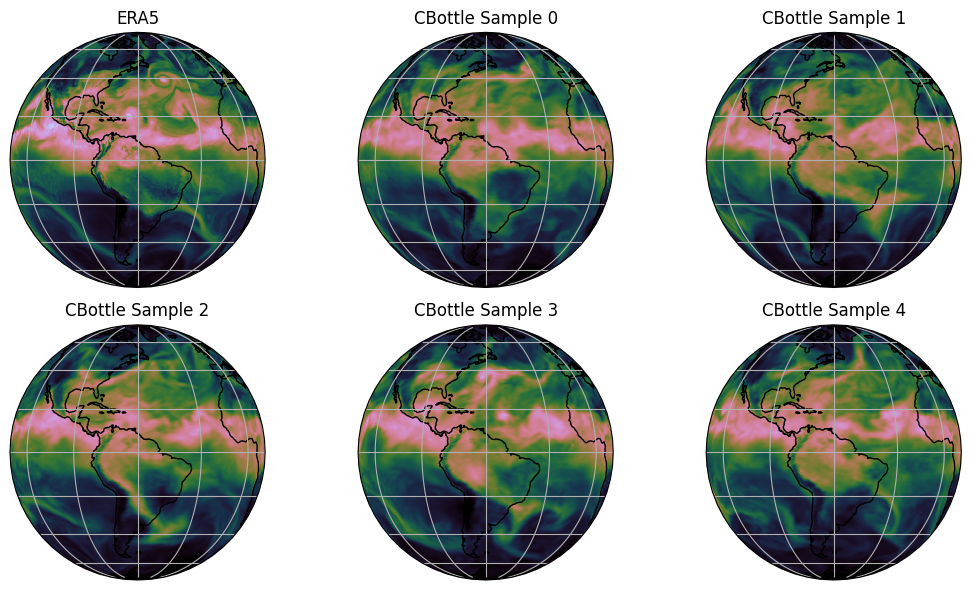

In [4]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

variable = "tcwv"

plt.close("all")
projection = ccrs.Orthographic(central_longitude=300.0)

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(2, 3, subplot_kw={"projection": projection}, figsize=(11, 6))
ax = ax.flatten()

ax[0].pcolormesh(
    era5_da.coords["lon"],
    era5_da.coords["lat"],
    era5_da.sel(variable=variable).isel(time=0),
    transform=ccrs.PlateCarree(),
    cmap="cubehelix",
)
ax[0].set_title("ERA5")

for i in range(n_samples):
    ax[i + 1].pcolormesh(
        cbottle_da.coords["lon"],
        cbottle_da.coords["lat"],
        cbottle_da.sel(variable=variable).isel(time=i),
        transform=ccrs.PlateCarree(),
        cmap="cubehelix",
        vmin=0,
        vmax=90,
    )
    ax[i + 1].set_title(f"CBottle Sample {i}")

for ax0 in ax:
    ax0.coastlines()
    ax0.gridlines()

plt.tight_layout()
plt.savefig("outputs/15_tcwv_cbottle_datasource.jpg")

## ตัวแปร Infilling ด้วย CBottleInfill Diagnostic
ต่อไปมาดูการใช้รุ่นเดียวกันแต่สำหรับการเติมตัวแปร
CBottleInfill ช่วยให้ผู้ใช้สามารถสร้างเขตข้อมูลสภาพอากาศทั่วโลกเช่นแหล่งข้อมูล แต่
กำหนดเงื่อนไขให้กับชุดช่องป้อนข้อมูลที่สามารถกำหนดค่าได้
ซึ่งหมายความว่าการวินิจฉัยนี้มีความยืดหยุ่นอย่างมากและสามารถใช้ได้กับทุกประเภท
ของแหล่งข้อมูลและโมเดล

เพื่อสาธิตสิ่งนี้ ให้พิจารณาสองกรณีของการวินิจฉัย infilling ด้วย
ชุดอินพุตที่แตกต่างกัน จากนั้นจึงเปรียบเทียบตัวแปรที่เติมเข้าไป
โปรดทราบว่าเอาต์พุตของการกำหนดค่าทั้งสองมีขนาดเท่ากันและมีขนาดเท่ากัน
ตัวแปร



In [5]:
import numpy as np

from earth2studio.data.utils import fetch_data

# ตัวแปรอินพุต
input_variables = ["u10m", "v10m"]

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = CBottleInfill.load_default_package()
model = CBottleInfill.load_model(package, input_variables=input_variables)
model = model.to(device)

torch.manual_seed(0)
torch.cuda.manual_seed(0)

times = np.array([timestamp] * n_samples, dtype="datetime64[ns]")
x, coords = fetch_data(era5_ds, times, input_variables, device=device)
output_0, output_coords = model(x, coords)
print(output_0.shape)

Fetching WB2 data:   0%|          | 0/10 [00:00<?, ?it/s]

2026-04-26 20:44:02.497 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2022-09-05T00:00:00
2026-04-26 20:44:02.497 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2022-09-05T00:00:00
2026-04-26 20:44:02.499 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2022-09-05T00:00:00
2026-04-26 20:44:02.500 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2022-09-05T00:00:00
2026-04-26 20:44:02.500 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2022-09-05T00:00:00
2026-04-26 20:44:02.501 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2022-09-05T00:00:00
2026-04-26 20:44:02.501 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2022-09-05T00:00:00

Fetching WB2 data:   0%|          | 0/10 [00:00<?, ?it/s]

2026-04-26 20:44:02.805 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_u_component_of_wind/93032.0.0 to local cache
2026-04-26 20:44:02.808 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_u_component_of_wind/93032.0.0 to local cache
2026-04-26 20:44:02.827 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_v_component_of_wind/93032.0.0 to local cache
2026-04-26 20:44:02.830 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_v_component_of_wind/93032.0.0 to local cache
2026-04-26 20:44:02.833 | DEBUG    | earth2studio.data.utils

Fetching WB2 data:   0%|          | 0/10 [00:00<?, ?it/s]

2026-04-26 20:44:03.013 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_u_component_of_wind/93032.0.0 to local cache
2026-04-26 20:44:03.017 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_u_component_of_wind/93032.0.0 to local cache
2026-04-26 20:44:03.025 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_v_component_of_wind/93032.0.0 to local cache


Fetching WB2 data:   0%|          | 0/10 [00:00<?, ?it/s]

2026-04-26 20:44:03.217 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/10m_u_component_of_wind/93032.0.0 to local cache


Fetching WB2 data: 100%|██████████| 10/10 [00:03<00:00,  3.18it/s]


torch.Size([5, 1, 45, 721, 1440])


ตอนนี้ทำซ้ำขั้นตอนข้างต้นแต่ใช้ชุดตัวแปรที่ขยายเพิ่ม
ในกรณีนี้ เราให้ข้อมูลมากขึ้นแก่โมเดลเพื่อกำหนดเงื่อนไขเพิ่มเติม
ข้อมูล.



In [6]:
input_variables = [
    "u10m",
    "v10m",
    "t2m",
    "msl",
    "z50",
    "u50",
    "v50",
    "z500",
    "u500",
    "v500",
    "z1000",
    "u1000",
    "v1000",
]

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = CBottleInfill.load_default_package()
model = CBottleInfill.load_model(package, input_variables=input_variables)
model = model.to(device)

torch.manual_seed(0)
torch.cuda.manual_seed(0)

x, coords = fetch_data(era5_ds, times, input_variables, device=device)
output_1, output_coords = model(x, coords)
print(output_1.shape)

Fetching WB2 data:   0%|          | 0/65 [00:00<?, ?it/s]

2026-04-26 20:44:41.655 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u500 at 2022-09-05T00:00:00
2026-04-26 20:44:41.657 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z50 at 2022-09-05T00:00:00
2026-04-26 20:44:41.659 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v500 at 2022-09-05T00:00:00
2026-04-26 20:44:41.660 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v1000 at 2022-09-05T00:00:00
2026-04-26 20:44:41.661 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v50 at 2022-09-05T00:00:00
2026-04-26 20:44:41.663 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t2m at 2022-09-05T00:00:00
2026-04-26 20:44:41.663 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u500 at 2022-09-05T00:00:00
2

2026-04-26 20:44:42.024 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.026 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.038 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.040 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/v_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.042 | DEBUG    | earth2studio.data.utils:_make_l

Fetching WB2 data:   0%|          | 0/65 [00:00<?, ?it/s]

2026-04-26 20:44:42.225 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.227 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.227 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.229 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.236 | DEBUG    | earth2studio.data.utils:_make_l

...

2026-04-26 20:44:42.738 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache
2026-04-26 20:44:42.774 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/u_component_of_wind/93032.0.0.0 to local cache


Fetching WB2 data:   0%|          | 0/65 [00:01<?, ?it/s]

2026-04-26 20:44:43.140 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/geopotential/93032.0.0.0 to local cache


Fetching WB2 data: 100%|██████████| 65/65 [00:34<00:00,  1.86it/s]


torch.Size([5, 1, 45, 721, 1440])


## กำลังประมวลผลภายหลัง CBottleInfill
เพื่อโพสต์การประมวลผลผลลัพธ์ เราจะดูตัวแปรที่เติมเข้าไป นั่นคือคอลัมน์น้ำทั้งหมด
ไอ.
เมื่อเปรียบเทียบกับตัวอย่างจาก CBottle3D แล้ว ผลลัพธ์จะสอดคล้องกันมากกว่ามาก
ความจริงภาคพื้นดินเนื่องจากโมเดล infill กำลังสุ่มตัวอย่างการแจกแจงแบบมีเงื่อนไข
นอกจากนี้ โมเดลที่มีตัวแปรเพิ่มเติมจะสอดคล้องกับพื้นได้ดีขึ้น
ความจริงเนื่องจากข้อมูลเพิ่มเติมที่ให้ไว้



Fetching WB2 data: 100%|██████████| 1/1 [00:00<00:00, 175.91it/s]

2026-04-26 20:45:49.107 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: tcwv at 2022-09-05T00:00:00


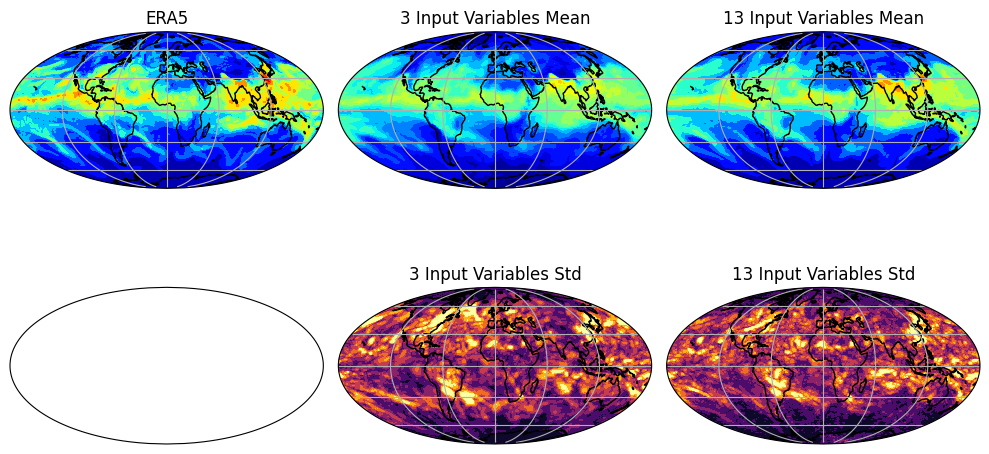

: 

In [ ]:
variable = "tcwv"
var_idx = np.where(output_coords["variable"] == "tcwv")[0][0]
era5_data, _ = fetch_data(era5_ds, times[:1], [variable], device=device)

plt.close("all")
projection = ccrs.Mollweide(central_longitude=0)

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(2, 3, subplot_kw={"projection": projection}, figsize=(10, 6))


def plot_contour(
    ax0: plt.axes,
    data: torch.Tensor,
    cmap: str = "jet",
    vrange: tuple[int, int] = (0, 90),
) -> None:
    """Contour helper"""
    ax0.contourf(
        output_coords["lon"],
        output_coords["lat"],
        data.cpu(),
        vmin=vrange[0],
        vmax=vrange[1],
        transform=ccrs.PlateCarree(),
        levels=12,
        cmap=cmap,
    )
    ax0.coastlines()
    ax0.gridlines()


plot_contour(ax[0, 0], era5_data[0, 0, 0])
plot_contour(ax[0, 1], torch.mean(output_0[:, 0, var_idx], axis=0))
plot_contour(ax[0, 2], torch.mean(output_1[:, 0, var_idx], axis=0))
plot_contour(
    ax[1, 1], torch.std(output_0[:, 0, var_idx], axis=0), cmap="inferno", vrange=(0, 10)
)
plot_contour(
    ax[1, 2], torch.std(output_1[:, 0, var_idx], axis=0), cmap="inferno", vrange=(0, 10)
)

ax[0, 0].set_title("ERA5")
ax[0, 1].set_title("3 Input Variables Mean")
ax[0, 2].set_title("13 Input Variables Mean")
ax[1, 1].set_title("3 Input Variables Std")
ax[1, 2].set_title("13 Input Variables Std")

plt.tight_layout()
plt.savefig("outputs/15_tcwv_cbottle_infill.jpg")